# Model Algoritma Populer dan Contohnya
Berikut adalah beberapa algoritma Unsupervised Learning yang paling sering digunakan beserta contoh penerapannya di dunia nyata:

1. K-Means Clustering: Pengelompokan Tingkat Keparahan Penyakit
Dalam skenario ini, kita memiliki data pasien berdasarkan dua indikator: Tekanan Darah dan Kadar Gula Darah. Kita ingin K-Means mengelompokkan pasien ke dalam 3 kelompok (misal: Risiko Rendah, Risiko Sedang, Risiko Tinggi) secara otomatis.

In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans

# 1. Simulasi Data Pasien (Tekanan Darah, Gula Darah)
np.random.seed(42)
data_pasien = np.random.randint(low=[90, 70], high=[180, 250], size=(20, 2))
df_kmeans = pd.DataFrame(data_pasien, columns=['Tekanan_Darah', 'Gula_Darah'])

# 2. Inisialisasi K-Means dengan 3 Cluster
kmeans = KMeans(n_clusters=3, random_state=42)
df_kmeans['Cluster_Risiko'] = kmeans.fit_predict(data_pasien)

print("--- Hasil K-Means Clustering Pasien ---")
print(df_kmeans.head())

--- Hasil K-Means Clustering Pasien ---
   Tekanan_Darah  Gula_Darah  Cluster_Risiko
0            141         162               1
1            104         176               0
2            161          90               1
3            172         144               1
4            164         157               1


2. Hierarchical Clustering: Struktur Hubungan Gejala Pasien
Misalkan kita ingin melihat bagaimana pasien-pasien ini mengelompok secara hierarki berdasarkan kemiripan gejala klinis mereka. Kita akan menghasilkan Dendrogram (pohon hierarki).

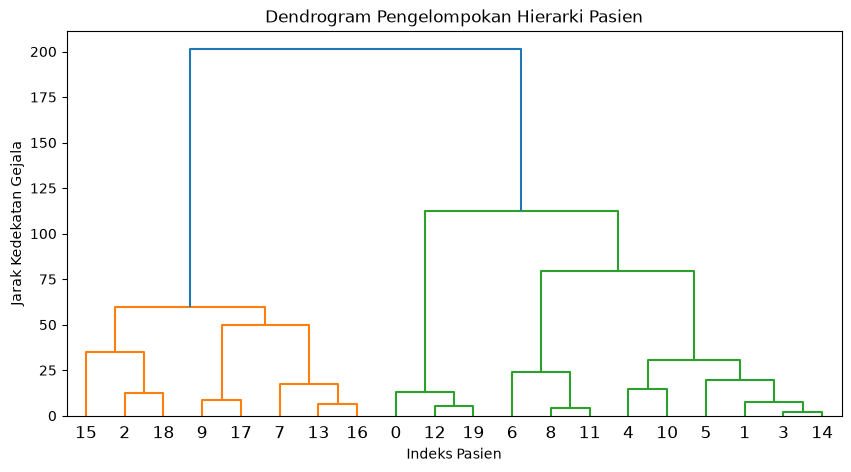

In [5]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import pandas as pd
import numpy as np

# Dummy data for df_kmeans (assuming similar structure to a K-Means output)
np.random.seed(42) # for reproducibility
df_kmeans = pd.DataFrame({
    'Tekanan_Darah': np.random.randint(90, 160, 20),
    'Gula_Darah': np.random.randint(70, 200, 20)
})

# Menggunakan data dari contoh K-Means di atas
data_hierarki = df_kmeans[['Tekanan_Darah', 'Gula_Darah']].values

# 1. Membuat matriks tautan (linkage matrix)
Z = linkage(data_hierarki, method='ward')

# 2. Membuat Dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Dendrogram Pengelompokan Hierarki Pasien")
plt.xlabel("Indeks Pasien")
plt.ylabel("Jarak Kedekatan Gejala")
plt.show()

3. Apriori Algorithm: Pola Komoriditas Gejala (Asosiasi)
Dalam dunia medis, gejala atau penyakit sering kali muncul bersamaan (komorbiditas). Kita ingin mencari tahu: "Jika pasien mengalami gejala A dan B, seberapa besar kemungkinan mereka juga mengalami gejala C?"

In [6]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)

from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

# 1. Simulasi Data Gejala yang Dialami Pasien (1 = Ya, 0 = Tidak)
rekam_medis = {
    'Demam':     [1, 1, 0, 1, 0, 1],
    'Batuk':     [1, 1, 0, 1, 1, 0],
    'Sesak_Napas':[0, 1, 1, 1, 0, 1],
    'Anosmia':   [0, 1, 1, 0, 0, 1]
}
df_apriori = pd.DataFrame(rekam_medis)

# Convert to boolean type to avoid deprecation warning
df_apriori = df_apriori.astype(bool)

# 2. Mencari kombinasi gejala yang sering muncul bersamaan (Minimal muncul di 50% data)
frequent_itemsets = apriori(df_apriori, min_support=0.5, use_colnames=True)

# 3. Membuat aturan asosiasi
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

print("--- Pola Hubungan Gejala (Apriori) ---")
# Menampilkan: Jika (antecedents) maka (consequents)
print(rules[['antecedents', 'consequents', 'support', 'confidence']])

--- Pola Hubungan Gejala (Apriori) ---
                antecedents               consequents  support  confidence
0        frozenset({Demam})        frozenset({Batuk})      0.5        0.75
1        frozenset({Batuk})        frozenset({Demam})      0.5        0.75
2  frozenset({Sesak_Napas})        frozenset({Demam})      0.5        0.75
3        frozenset({Demam})  frozenset({Sesak_Napas})      0.5        0.75
4  frozenset({Sesak_Napas})      frozenset({Anosmia})      0.5        0.75
5      frozenset({Anosmia})  frozenset({Sesak_Napas})      0.5        1.00


4. PCA (Principal Component Analysis): Mereduksi Data Genetik/Laboratorium yang Kompleks, Bayangkan seorang pasien melakukan tes laboratorium komprehensif yang menghasilkan puluhan metrik (Fitur 1 sampai Fitur 5). PCA digunakan untuk menyederhanakan puluhan komponen tersebut menjadi 2 komponen utama saja (PC1 & PC2) agar dokter lebih mudah memvisualisasikan kondisi pasien atau memasukkannya ke model diagnosis berikutnya.

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Simulasi Data Laboratorium Kompleks (5 Fitur Medis berbeda)
data_lab = {
    'Kolesterol': [210, 180, 240, 190, 300],
    'Trigliserida': [150, 130, 210, 140, 290],
    'Asam_Urat': [6.5, 5.0, 7.2, 4.8, 8.5],
    'Hemoglobin': [14, 15, 12, 13, 11],
    'Leukosit': [7000, 6500, 8000, 7200, 11000]
}
df_lab = pd.DataFrame(data_lab)

# 2. Standardisasi Data (Penting sebelum melakukan PCA)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(df_lab)

# 3. Reduksi dari 5 Fitur menjadi 2 Komponen Utama (PCA)
pca = PCA(n_components=2) # Corrected: n_components
data_pca = pca.fit_transform(data_scaled)

df_hasil_pca = pd.DataFrame(data_pca, columns=['PC1 (Kondisi_Umum)', 'PC2 (Kondisi_Darah)'])
print("--- Hasil Reduksi Dimensi dengan PCA ---")
print(df_hasil_pca)

--- Hasil Reduksi Dimensi dengan PCA ---
   PC1 (Kondisi_Umum)  PC2 (Kondisi_Darah)
0           -0.945145             0.565286
1           -2.334247             0.314110
2            0.941617            -0.083450
3           -1.413691            -0.838702
4            3.751466             0.042756
